In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.2)

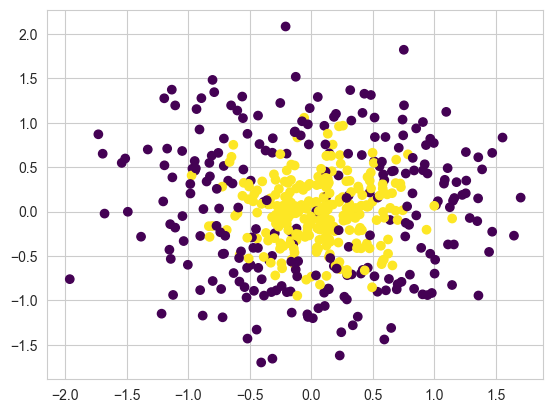

In [15]:
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis')

In [5]:
import warnings
warnings.filterwarnings("ignore")

In [6]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.base import clone

def evaluateModelAccuracy(model):
    copyModel = clone(model)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Cross Val Score": (cross_val_score(copyModel, X,y,scoring='accuracy',cv=5)).mean()
    }

In [7]:
from sklearn.ensemble import RandomForestClassifier


rf = RandomForestClassifier(
    n_estimators=20,
    max_features=0.6,
    max_depth=8,
    max_samples=0.75
)
print(evaluateModelAccuracy(rf))

{'Accuracy': 0.795, 'Cross Val Score': np.float64(0.8039999999999999)}


# All possible case : Grid Search CV

In [8]:
params = {
    'n_estimators' : [20,60],
    'max_features' : [0.4,0.6,1.0],
    'max_depth' : [2,8,None],
    'max_samples' : [0.5,0.75,1.0]
}

In [9]:
from sklearn.model_selection import ParameterGrid

grid = ParameterGrid(params)
print(len(grid))

54


In [10]:
from sklearn.model_selection import GridSearchCV

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(),
    param_grid= params,
    cv=5,
    verbose=2,
    n_jobs=-1
)

In [11]:
rf_grid.fit(X_train,y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 8, ...], 'max_features': [0.4, 0.6, ...], 'max_samples': [0.5, 0.75, ...], 'n_estimators': [20, 60]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate 

In [12]:
rf_grid.best_score_

np.float64(0.8699999999999999)

In [13]:
rf_grid.best_params_

{'max_depth': None,
 'max_features': 0.6,
 'max_samples': 0.5,
 'n_estimators': 60}

In [14]:
best_model = rf_grid.best_estimator_
print(evaluateModelAccuracy(best_model))

{'Accuracy': 0.78, 'Cross Val Score': np.float64(0.8119999999999999)}


# Plotting

In [20]:
def plotRegion(classfier_model):
    plt.figure(figsize=(12,8))
    plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=0.7)
    
    x_range = np.linspace(X.min() , X.max(), 100)
    xx1, xx2 = np.meshgrid(x_range, x_range)
    
    y_pred = classfier_model.predict(np.c_[xx1.ravel(), xx2.ravel()]).reshape(xx1.shape)
    plt.contourf(xx1, xx2, y_pred, alpha=0.2)
    plt.show()

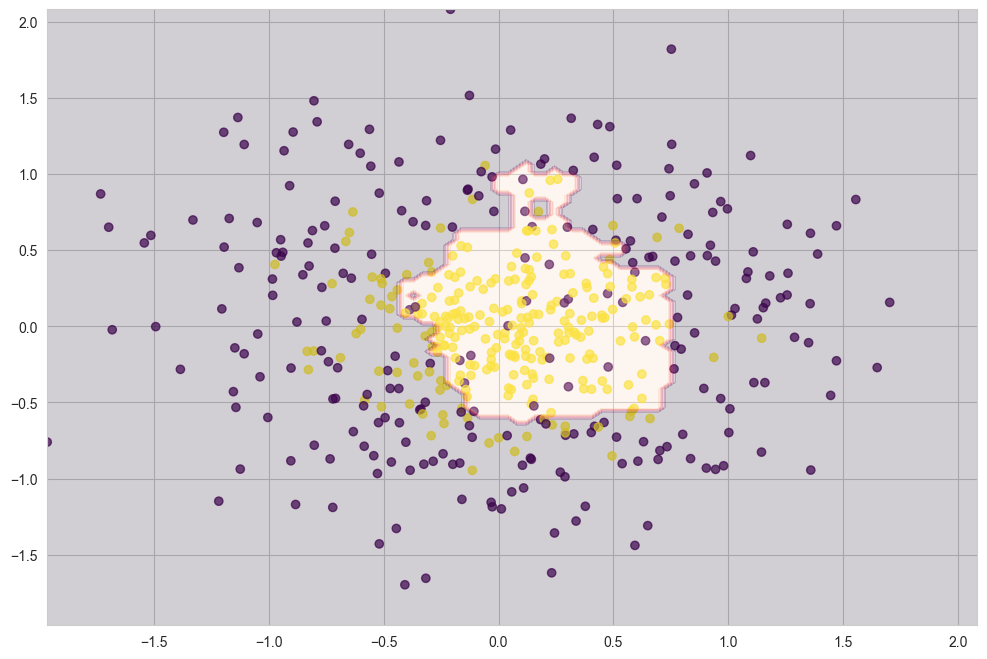

In [21]:
plotRegion(best_model)